In [1]:
from graph_transformer_long_range_niches.tl import pad_batch
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, FIG_PATH, LEGNINI23
from graph_transformer_long_range_niches.model import LitGNNTransformer
from graph_transformer_long_range_niches.pl import CustomColormap, plot_attention_sender_receiver, plot_attention_sender_receiver, SelfAttentionRelevance, calculate_attention, normalized_attention, normalized_class_attention
from graph_transformer_long_range_niches.pp import prepare_geome_dataset, split_adata
from graph_transformer_long_range_niches.config import load_config

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle

import scanpy as sc
import squidpy as sq

from sklearn.preprocessing import MinMaxScaler

In [2]:
FOLDER = "legnini23"
GEX_DATA = "legnini23_None_sample_1_44"

In [3]:
def load_model(PATH, model_type = "gnn-transformer", RESULTS = RESULTS, FOLDER = FOLDER):
    model_transformer_ckpt = torch.load(Path(RESULTS, FOLDER, f"{PATH}_{model_type}.ckpt"))
    cfg = model_transformer_ckpt['hyper_parameters']['cfg']
    model_transformer = LitGNNTransformer(model_transformer_ckpt['hyper_parameters']['cfg'])
    model_transformer.load_state_dict(model_transformer_ckpt['state_dict'])
    obs_csv = pd.read_csv(Path(RESULTS, FOLDER, f"{PATH}_obs.csv"))
    obs_csv = obs_csv.rename(columns={'Unnamed: 0': 'obs_names'})
    return model_transformer, cfg, obs_csv

# Evaluation: Legnini et. al, 2023

Legnini, I., Emmenegger, L., Zappulo, A. et al. Spatiotemporal, optogenetic control of gene expression in organoids. Nat Methods 20, 1544–1552 (2023). https://doi.org/10.1038/s41592-023-01986-w

## Load the model checkpoint and data

In [4]:
model_transformer_gex, cfg_gex, obs_gex = load_model(GEX_DATA, model_type = "gnn-transformer")

num features: 88


In [5]:
adata = sc.read_h5ad(Path(LEGNINI23))
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'sliding_window_assignment', 'globalX', 'globalY', 'obs_names'
    obsm: 'spatial'

In [6]:
adata.obs['split'] = np.array(obs_gex['split'].values)

In [7]:
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'sample', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  sample       condition
train  slide1_D2-2  SHH          4318
       slide1_D2-3  SHH          3621
val    slide1_C2-2  SHH          3510
train  slide4_B2-1  SHH          3345
       slide1_B2-1  SHH          3299
val    slide1_A2-1  SHH          3023
train  slide1_C2-1  Ctrl         2870
       slide4_A2-1  SHH          2630
       slide4_A2-2  SHH          2506
val    slide1_B2-3  SHH          2241
test   slide4_A2-3  Ctrl         1984
val    slide1_C2-5  Ctrl         1958
test   slide4_B2-2  SHH          1779
train  slide1_B2-2  Ctrl         1701
       slide1_A2-2  SHH          1694
       slide4_B2-3  Ctrl         1643
       slide1_C2-3  Ctrl         1640
Name: count, dtype: int64


Q: Is the only covariate the condition or are the sample slices also different in other aspects???

## Inference 

In [8]:
sub_adata_ctrl, attention_matrix_dict_ctrl, trans_in_dict_ctrl, trans_out_dict_ctrl, dec_out = calculate_attention(adata, cfg_gex, model_transformer_gex, obs_col = 'sample', class_name = 'slide4_A2-3', library_key=None)
sub_adata_shh, attention_matrix_dict_shh, trans_in_dict_shh, trans_out_dict_shh, dec_out_shh = calculate_attention(adata, cfg_gex, model_transformer_gex, obs_col = 'sample', class_name = 'slide4_B2-2', library_key=None)

call new
call new
call new
test
call new
DataBatch(x=[1984, 88], edge_index=[2, 4], obs_names=[1984], batch=[1984], ptr=[2]) None
Category mask:  torch.Size([1985, 1, 128])
1985
Layer 1 attention gradient shape: torch.Size([4, 1985, 1985])
Layer 1 attention output weights shape: torch.Size([4, 1985, 1985])
Average attention map shape: torch.Size([1985, 1985])
I:  tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
Layer 2 attention gradient shape: torch.Size([4, 1985, 1985])
Layer 2 attention output weights shape: torch.Size([4, 1985, 1985])
Average attention map shape: torch.Size([1985, 1985])
I:  tensor([[1.0000e+00, 4.7026e-07, 9.9728e-07,  ..., 3.3204e-07, 8.2173e-07,
         4.3304e-06],
        [3.4073e-10, 1.0000e+00, 3.8734e-10,  ..., 3.8796e-10, 4.5987e-10,
         1.8904e-10]

In [24]:
trans_in_dict_ctrl

{None: tensor([[[ 9.2696,  4.4700,  6.7941,  ...,  4.5390,  2.9622, -0.8145]],
 
         [[10.8332,  6.3706, 14.8387,  ...,  0.9367,  5.0681, -4.4147]],
 
         [[ 7.6546,  4.0673,  6.4214,  ..., -0.2897,  2.4136, -2.2315]],
 
         ...,
 
         [[ 2.3496,  1.4554,  1.8257,  ...,  0.9920,  0.0400, -0.5398]],
 
         [[ 3.8926,  2.9556,  5.1080,  ..., -0.3491,  1.4389, -0.2807]],
 
         [[ 1.0813,  1.0862,  2.1664,  ..., -0.2960,  0.4451, -0.7592]]],
        grad_fn=<CopySlices>)}

In [75]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

def compute_r2_per_gene(X_train, y_train, X_test, y_test, alpha=1.0):
    """
    Compute R^2 for each gene using Ridge regression.
    
    Parameters:
    - X_train, X_test: Embeddings (n_samples x n_features)
    - y_train, y_test: Gene expression (n_samples x n_genes)
    - alpha: Regularization strength for Ridge regression

    Returns:
    - r2_per_gene: Array of R^2 scores for each gene
    """
    n_genes = y_train.shape[1]
    r2_per_gene = []
    
    for gene_idx in range(n_genes):
        # Select the gene to predict
        y_train_gene = y_train[:, gene_idx]
        y_test_gene = y_test[:, gene_idx]
        
        # Train Ridge regression model
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train_gene)
        y_pred_gene = model.predict(X_test)
        
        # Compute R^2 for the gene
        r2_gene = r2_score(y_test_gene, y_pred_gene)
        r2_per_gene.append(r2_gene)
    
    return np.array(r2_per_gene)

def analyze_per_gene_variance(Z_GNN, Z_Transformer, Y, alpha=1.0, cv_splits=5, top_genes:int = 5):
    """
    Analyze variance explained per gene and find top genes.
    
    Parameters:
    - Z_GNN: Embeddings from GNN (n_samples x n_features)
    - Z_Transformer: Embeddings from Transformer (n_samples x n_features)
    - Y: Target gene expressions (n_samples x n_genes)
    - alpha: Regularization strength for Ridge regression
    - cv_splits: Number of cross-validation splits

    Returns:
    - top_genes_gnn: Top genes based on R^2 for Z_GNN
    - top_genes_transformer: Top genes based on R^2 for Z_Transformer
    - r2_gnn_mean: Mean R^2 scores for Z_GNN per gene
    - r2_transformer_mean: Mean R^2 scores for Z_Transformer per gene
    """
    n_genes = Y.shape[1]
    r2_gnn_all = np.zeros((cv_splits, n_genes))
    r2_transformer_all = np.zeros((cv_splits, n_genes))
    
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(Y)):
        # Split data
        Z_GNN_train, Z_GNN_test = Z_GNN[train_idx], Z_GNN[test_idx]
        Z_Transformer_train, Z_Transformer_test = Z_Transformer[train_idx], Z_Transformer[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]
        
        # Compute R^2 per gene for GNN
        r2_gnn_all[fold_idx, :] = compute_r2_per_gene(Z_GNN_train, Y_train, Z_GNN_test, Y_test, alpha)
        
        # Compute R^2 per gene for Transformer
        r2_transformer_all[fold_idx, :] = compute_r2_per_gene(Z_Transformer_train, Y_train, Z_Transformer_test, Y_test, alpha)
    
    # Mean R^2 across folds
    r2_gnn_mean = r2_gnn_all.mean(axis=0)
    r2_transformer_mean = r2_transformer_all.mean(axis=0)
    
    # Identify top genes
    top_genes_gnn = np.argsort(-r2_gnn_mean)[:top_genes]  # Top 5 genes for GNN
    top_genes_transformer = np.argsort(-r2_transformer_mean)[:top_genes]  # Top 5 genes for Transformer
    
    return top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean

In [80]:
Z_local_ctrl = trans_in_dict_ctrl[None].detach().numpy().squeeze(1)
Z_local_shh = trans_in_dict_shh[None].detach().numpy().squeeze(1)
Z_local.shape

(1984, 128)

In [81]:
Z_global_ctrl = trans_out_dict_ctrl[None].detach().numpy().squeeze(1)
Z_global_shh = trans_out_dict_shh[None].detach().numpy().squeeze(1)
Z_global.shape

(1984, 128)

In [84]:
# Compute per-gene R^2 and find top-performing genes
top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean = analyze_per_gene_variance(
    Z_local_ctrl, Z_global_ctrl, sub_adata_ctrl.X.toarray(), alpha=1.0, cv_splits=5, top_genes = 10
)

# Print results
print("Top genes for GNN (indices):", sub_adata_ctrl.var_names[top_genes_gnn])
print("Top genes for Transformer (indices):", sub_adata_ctrl.var_names[top_genes_transformer])
print("R^2 mean for GNN:", r2_gnn_mean)
print("R^2 mean for Transformer:", r2_transformer_mean)

Top genes for GNN (indices): Index(['TREM2', 'OLIG1', 'NKX2.1', 'ARG1', 'Circ.CDR1', 'Circ.RMST', 'TUBB3',
       'PAX6', 'STMN2', 'PTPRZ1'],
      dtype='object')
Top genes for Transformer (indices): Index(['TREM2', 'OLIG1', 'NKX2.1', 'ARG1', 'STMN2', 'JUN', 'TUBB3', 'MAP2',
       'PAX6', 'PROM1'],
      dtype='object')
R^2 mean for GNN: [ 0.70761254  0.81237121  0.00325397 -0.14129858 -0.10128174  0.32659594
  1.         -0.14228575 -0.27907915  0.11512198 -0.1067543  -0.28601911
  0.04751796  0.98537321  0.97846249  0.7467706   0.61926765  0.40479598
  0.53666446 -0.01605462 -0.2119559  -0.1981539   0.57134321  0.14853116
 -0.10362571  0.47658763  0.59768558  0.00536656  0.04738876  0.33579686
  0.53594     0.89027405  0.92411604  0.37651255  0.15456493  0.02762663
  0.61604801 -0.09531031  0.21482209  0.91741506 -0.16803505  0.85551598
  0.40009953  0.76991339  0.0850382  -0.22484081  0.94746277 -0.17428632
 -0.08282051  0.56625459  0.02922508  0.04362615  0.24969243  1.
 -0.09332

In [83]:
# Compute per-gene R^2 and find top-performing genes
top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean = analyze_per_gene_variance(
    Z_local_shh, Z_global_shh, sub_adata_shh.X.toarray(), alpha=1.0, cv_splits=5, top_genes = 10
)

# Print results
print("Top genes for GNN (indices):", sub_adata_shh.var_names[top_genes_gnn])
print("Top genes for Transformer (indices):", sub_adata_shh.var_names[top_genes_transformer])
print("R^2 mean for GNN:", r2_gnn_mean)
print("R^2 mean for Transformer:", r2_transformer_mean)

Top genes for GNN (indices): Index(['TREM2', 'FOXG1', 'NKX2.1', 'SIX6', 'Circ.CDR1', 'STMN2', 'TUBB3',
       'SHH', 'NKX6.1', 'Circ.RMST'],
      dtype='object')
Top genes for Transformer (indices): Index(['SIX6', 'TREM2', 'FOXG1', 'NKX2.1', 'STMN2', 'PAX6', 'SHH', 'NKX6.1',
       'FOXA1', 'GLI3'],
      dtype='object')
R^2 mean for GNN: [ 0.75625817  0.80025476 -0.12742233 -0.13785198 -0.16974993  0.28156282
 -0.22768347 -0.19187312 -0.07647877 -0.23390393 -0.07953691  0.40063547
  0.07452402  0.97863708  0.95358244  0.70878162  0.35275592  0.73066338
  0.66116714 -0.0986573  -0.23139522 -0.16723413  0.54276012  0.21320912
  0.29930997  0.89026849  0.86276352  0.0491073  -0.06583241  0.55975213
  0.55133294  0.76369359  0.81617991  0.10291121  0.21009226  0.33407788
  0.39425452 -0.18222106  0.50682622  0.75118876  0.63435975  0.72853041
  0.25796959  0.65013723 -0.04386036 -0.10197871  0.9364557   0.55848473
 -0.14924233 -0.00368413 -0.10488094  0.46861533  0.63291253  1.
  0.74805

In [87]:
def local_global_variance_composition(r2_gnn_mean, r2_transformer_mean, var_names, n_genes=10):
    """
    Plot normalized variance composition for the top `n_genes` genes with the highest variance explained.
    
    Parameters:
    - r2_gnn_mean: Array of variance explained by the GNN.
    - r2_transformer_mean: Array of variance explained by the Transformer.
    - var_names: List of gene names corresponding to the variance arrays.
    - n_genes: Number of top genes to plot based on total explained variance.
    """
    # Compute unexplained variance (1 - max variance explained by GNN or Transformer)
    unexplained_variance = 1 - np.maximum(r2_gnn_mean, r2_transformer_mean)
    
    # Total variance normalization (Local + Global + Noise)
    total_variance = r2_gnn_mean + r2_transformer_mean + unexplained_variance
    
    # Normalize variances
    normalized_local = r2_gnn_mean / total_variance
    normalized_global = r2_transformer_mean / total_variance
    normalized_noise = unexplained_variance / total_variance
    
    # Rank genes by total explained variance (GNN + Transformer)
    explained_variance = r2_gnn_mean + r2_transformer_mean
    top_indices = np.argsort(-explained_variance)[:n_genes]  # Get indices of top genes
    
    # Select top genes and their corresponding variances
    top_local = normalized_local[top_indices]
    top_global = normalized_global[top_indices]
    top_noise = normalized_noise[top_indices]
    top_gene_names = [var_names[i] for i in top_indices]
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(top_gene_names))
    
    # Plot normalized variances
    ax.bar(x, top_local, color='green', label='GNN (Local)')
    ax.bar(x, top_global, bottom=top_local, color='blue', label='Transformer (Global)')
    ax.bar(x, top_noise, bottom=top_local + top_global, color='gray', label='Unexplained')
    
    # Customize plot
    ax.set_xticks(x)
    ax.set_xticklabels(top_gene_names, rotation=45, ha='right')
    ax.set_ylabel('Normalized Variance Explained')
    ax.set_title(f'Normalized Variance Explained for Top {n_genes} Genes')
    ax.set_ylim(0, 1)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

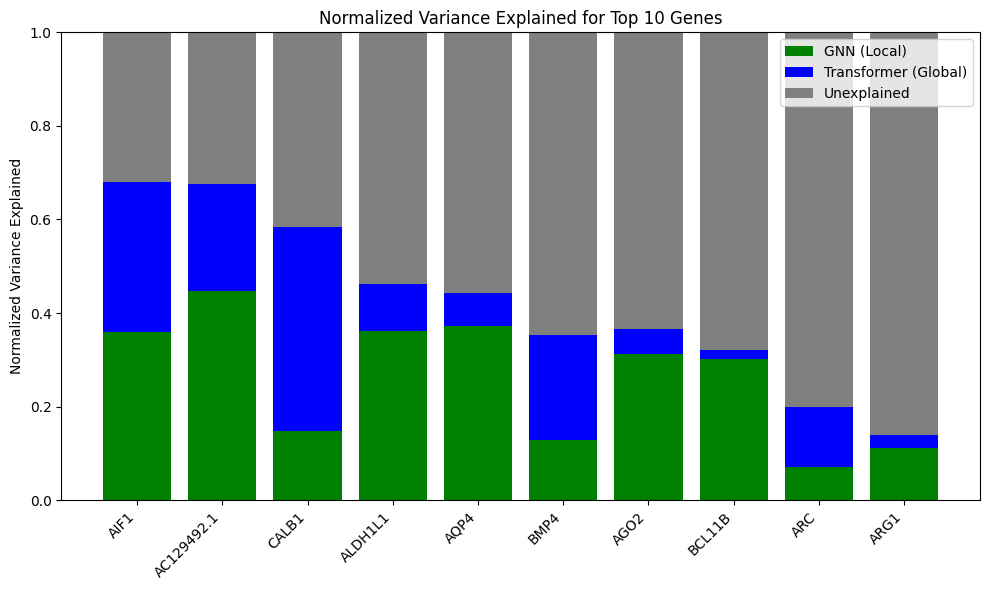

In [88]:
local_global_variance_composition(r2_gnn_mean, r2_transformer_mean, sub_adata_shh.var_names, n_genes=10)